# DtN validation on the finite cylinder — comparison with the reference solution

**Research Project — 2A IM, Mines Nancy**
*Massaro Elias — Supervisor: M. Dos Santos Ferreira*

This notebook checks the matrix formula for the wave-equation DtN operator on the
cylinder by superimposing on a single plot:

- the **reference solution** obtained by high-resolution finite differences
  on the axial 1D PDE (for a known $f$);
- the **spectral formula (11)** obtained by Mittag-Leffler expansion of the
  matrix symbol.

## Recalling the problem

The hollow cylinder $\Omega = S^1_R \times (0, L)$ has two boundaries: $\Gamma_0 = \{z=0\}$
and $\Gamma_L = \{z=L\}$. The wave equation

$$\partial_t^2 u - \Delta_\Omega u = 0, \qquad
\Delta_\Omega = \frac{1}{R^2}\partial_\theta^2 + \partial_z^2,$$

is endowed with two Dirichlet conditions:
$u(\theta, 0, t) = f_0(\theta, t)$, $u(\theta, L, t) = f_L(\theta, t)$.

The DtN operator is **matrix-valued**:

$$\Lambda\!\begin{pmatrix}f_0 \\ f_L\end{pmatrix} =
\begin{pmatrix}-\partial_z u\big|_{z=0} \\ +\partial_z u\big|_{z=L}\end{pmatrix}$$

## Formula (11) to be validated

After the angular Fourier transform (mode $m$) and the temporal Laplace transform, with
$\mu_m(s) = \sqrt{s^2 + (m/R)^2}$:

$$\widehat{\Lambda}_m(s) =
\begin{pmatrix} \mu_m \coth(\mu_m L) & -\mu_m/\sinh(\mu_m L) \\
-\mu_m/\sinh(\mu_m L) & \mu_m \coth(\mu_m L) \end{pmatrix}$$

By Mittag-Leffler expansion (with $\alpha = (m/R)^2$ and
$\omega_{m,k}^2 = (k\pi/L)^2 + \alpha$):

$$\mu_m \coth(\mu_m L) = \frac{1}{L} + \frac{2}{L}\sum_{k=1}^\infty \frac{s^2 + \alpha}{s^2 + \omega_{m,k}^2}, \qquad
\frac{\mu_m}{\sinh(\mu_m L)} = \frac{1}{L} + \frac{2}{L}\sum_{k=1}^\infty \frac{(-1)^k (s^2 + \alpha)}{s^2 + \omega_{m,k}^2}$$

By derivative transfer (using $f(0)=f'(0)=0 \Rightarrow s^2\hat f = \mathcal L\{f''\}$),
one obtains the time-domain expression:

$$[N f](t) = \frac{f(t)}{L} + \frac{2}{L}\sum_k \int_0^t \frac{\sin(\omega_{m,k}(t-\tau))}{\omega_{m,k}} \big[f''(\tau) + \alpha f(\tau)\big]\, d\tau$$

$$[D f](t) = \frac{f(t)}{L} + \frac{2}{L}\sum_k (-1)^k \int_0^t \frac{\sin(\omega_{m,k}(t-\tau))}{\omega_{m,k}} \big[f''(\tau) + \alpha f(\tau)\big]\, d\tau$$

and the DtN flux reads:

$$[\Lambda]_0 = N \!\ast\! f_0 - D \!\ast\! f_L, \qquad
[\Lambda]_L = -D \!\ast\! f_0 + N \!\ast\! f_L$$

In [1]:
# =============================================================================
#  Imports and environment configuration
# =============================================================================

import numpy as np                 # vector/matrix computation (arrays, linear algebra)
import matplotlib.pyplot as plt    # plotting of the validation curves

# Display the figures directly in the notebook (rather than in a separate window).
%matplotlib inline

# Figure resolution (dots per inch): 110 dpi -> sharp, legible rendering
# while keeping the files reasonably light.
plt.rcParams['figure.dpi'] = 110

## 1 — Reference solution (high-resolution finite differences)

For a known $f$ and a fixed mode $m$, we solve the axial 1D PDE numerically:

$$\partial_t^2 u_m - \partial_z^2 u_m + \left(\frac{m}{R}\right)^2 u_m = 0, \quad z \in (0, L)$$

with the conditions $u_m(0, t) = f_{0,m}(t)$ and $u_m(L, t) = f_{L,m}(t)$ and
vanishing initial conditions. We use a classical centered scheme (order 2 in space and
in time), and we compute the outgoing fluxes by second-order one-sided differences.

With $N_z = 1000$ points and a fine temporal grid, this solution reaches
an accuracy of order $10^{-4}$ or better — it serves as a **quasi-exact
reference** for formula (11).

In [2]:
def solve_wave_cylinder_mode(m, R, L, f0, fL, T, Nz=1000, CFL=0.4):
    """
    Solves, for a mode m:
        d_t^2 u - d_z^2 u + (m/R)^2 u = 0,   z in (0, L)
        u(0, t) = f_0(t), u(L, t) = f_L(t),  vanishing initial conditions

    Returns (t_array, flux_0, flux_L) with
        flux_0[i] = -d_z u(z=0, t_i)
        flux_L[i] = +d_z u(z=L, t_i)

    This is the REFERENCE SOLUTION: we discretize the axial 1D PDE
    (Klein-Gordon equation) directly by a second-order centered finite
    difference scheme, at high resolution, so as to provide a yardstick for
    the spectral formula (11).
    """
    # --- Spatial discretization --------------------------------------------
    dz = L / Nz                 # space step: L divided into Nz intervals

    # --- Temporal discretization -------------------------------------------
    # CFL condition: dt proportional to dz to guarantee the stability of the
    # explicit scheme (CFL = 0.4 < 1, a comfortable safety margin).
    dt = CFL * dz
    Nt = int(np.ceil(T / dt))   # number of steps needed to cover [0, T]
    dt = T / Nt                 # dt is rectified so as to land exactly on T

    # Mass term of the Klein-Gordon equation: (m/R)^2 (= alpha).
    mass_sq = (m / R) ** 2

    # --- Buffers for the three-time-level scheme ---------------------------
    # The time-centered scheme relates u^{n-1}, u^n and u^{n+1}.
    u_prev = np.zeros(Nz + 1)   # u at time step n-1
    u_curr = np.zeros(Nz + 1)   # u at time step n   (Nz+1 nodes: indices 0..Nz)
    u_next = np.zeros(Nz + 1)   # u at time step n+1

    # Temporal grid and output arrays for the fluxes at the two boundaries.
    t_array = np.linspace(0, T, Nt + 1)
    flux_0 = np.zeros(Nt + 1)   # outgoing flux at z = 0
    flux_L = np.zeros(Nt + 1)   # outgoing flux at z = L

    # --- Time-marching loop -------------------------------------------------
    for step in range(Nt):
        t_new = (step + 1) * dt          # the time t^{n+1} being computed

        # Dirichlet conditions imposed at the current time t^n:
        u_curr[0]  = f0(step * dt)       # boundary z = 0
        u_curr[-1] = fL(step * dt)       # boundary z = L

        # Second-order discrete Laplacian (3-point centered scheme) on the
        # interior nodes only (indices 1 .. Nz-1).
        d2z = (u_curr[2:] - 2*u_curr[1:-1] + u_curr[:-2]) / dz**2

        # Full spatial operator: d_z^2 u - (m/R)^2 u
        L_m = d2z - mass_sq * u_curr[1:-1]

        # Leapfrog scheme in time, order 2:
        #   u^{n+1} = 2 u^n - u^{n-1} + dt^2 * (d_z^2 u - alpha u)
        u_next[1:-1] = 2*u_curr[1:-1] - u_prev[1:-1] + dt**2 * L_m

        # Boundary conditions at the new time t^{n+1}.
        u_next[0]  = f0(t_new)
        u_next[-1] = fL(t_new)

        # --- Outgoing fluxes: second-order one-sided normal derivative -----
        # At z=0, "forward" one-sided 3-point scheme:
        #   u'(0) ~ (-3 u_0 + 4 u_1 - u_2) / (2 dz)
        d_plus  = (-3*u_next[0]  + 4*u_next[1]  - u_next[2])  / (2 * dz)
        # At z=L, the symmetric "backward" one-sided scheme:
        #   u'(L) ~ ( 3 u_N - 4 u_{N-1} + u_{N-2}) / (2 dz)
        d_minus = ( 3*u_next[-1] - 4*u_next[-2] + u_next[-3]) / (2 * dz)

        # DtN sign conventions:
        #   flux_0 = -d_z u|_{z=0}  (outward normal oriented towards -z)
        #   flux_L = +d_z u|_{z=L}  (outward normal oriented towards +z)
        flux_0[step + 1] = -d_plus
        flux_L[step + 1] = +d_minus

        # Buffer rotation: u_prev is recycled for the next u_next
        # (avoids any memory reallocation inside the loop).
        u_prev, u_curr, u_next = u_curr, u_next, u_prev

    return t_array, flux_0, flux_L

## 2 — Evaluation of formula (11)

We implement the matrix computation from the Mittag-Leffler expansion,
using the trapezoidal quadrature on the temporal grid.

In [3]:
def dtn_spectral_cylinder_mode(m, R, L, t_array,
                               f0_vals, fL_vals, f0_dd_vals, fL_dd_vals,
                               k_modes=100):
    """Evaluates the two components ([Lambda]_0, [Lambda]_L) via formula (11).

    Implements the Mittag-Leffler expansion: each flux is a truncated
    sum (k = 1 .. k_modes) of temporal convolutions whose kernel is
    sin(omega_{m,k}*(t-tau)) / omega_{m,k}.
    The convolutions are approximated by trapezoidal quadrature.
    """
    Nt = len(t_array)
    dt = t_array[1] - t_array[0]      # time step (grid assumed uniform)
    alpha = (m / R) ** 2             # mass term alpha = (m/R)^2

    # --- Eigenfrequencies omega_{m,k}^2 = (k pi/L)^2 + alpha ---------------
    ks = np.arange(1, k_modes + 1)                       # axial indices k = 1..k_modes
    omegas = np.sqrt((ks * np.pi / L)**2 + alpha)        # associated angular frequencies

    # --- Matrix of the time differences (t - tau) -------------------------
    # T_diff[i, j] = t_i - t_j; the convolution kernel depends only on
    # this difference (causal system -> the part t - tau >= 0 only).
    T_diff = t_array[:, None] - t_array[None, :]
    mask = T_diff >= 0               # causality mask (lower triangle)

    # --- Trapezoidal quadrature weights, row by row -----------------------
    # W[i, :] holds the trapezoidal weights for integrating from tau=0 to tau=t_i:
    #   endpoints weighted dt/2, interior points weighted dt.
    W = np.zeros((Nt, Nt))
    for i in range(1, Nt):
        W[i, 0]  = dt / 2                       # weight of the first point
        if i > 1: W[i, 1:i] = dt                # weights of the interior points
        W[i, i]  = dt / 2                       # weight of the last point (tau = t_i)

    # Defensive conversion to float arrays (in case lists are passed in).
    f0    = np.asarray(f0_vals, dtype=float)
    fL    = np.asarray(fL_vals, dtype=float)
    f0_dd = np.asarray(f0_dd_vals, dtype=float)
    fL_dd = np.asarray(fL_dd_vals, dtype=float)

    # Convolved source g(tau) = f''(tau) + alpha f(tau), arising from the derivative
    # transfer (s^2 f_hat corresponds to L{f''} since f(0)=f'(0)=0).
    g0 = f0_dd + alpha * f0
    gL = fL_dd + alpha * fL

    # --- Constant terms 1/L (term k=0 of the expansion) -------------------
    # N and D share the same constant term; they differ only by the
    # sign (-1)^k of the terms of the series.
    N_f0 = f0 / L; N_fL = fL / L
    D_f0 = f0 / L; D_fL = fL / L

    # --- Spectral sum over the axial modes k ------------------------------
    for k, omega in zip(ks, omegas):
        sign = (-1) ** k                                  # alternating sign of the D kernel

        # Convolution kernel sin(omega (t-tau))/omega, set to zero where t < tau (causality).
        K = np.where(mask, np.sin(omega * T_diff) / omega, 0.0)

        # Entrywise multiplication by the trapezoidal weights: M realizes
        # the discrete convolution operator (matrix-vector product).
        M = W * K

        # Convolution = matrix-vector product: (M @ g)[i] ~ int_0^{t_i} K g dtau
        conv_0 = M @ g0
        conv_L = M @ gL

        # Accumulation into the kernels N (sign +) and D (alternating sign).
        N_f0 += (2.0 / L) * conv_0
        N_fL += (2.0 / L) * conv_L
        D_f0 += (2.0 / L) * sign * conv_0
        D_fL += (2.0 / L) * sign * conv_L

    # --- Matrix assembly of the DtN flux ----------------------------------
    #   [Lambda]_0 =  N * f_0 - D * f_L
    #   [Lambda]_L = -D * f_0 + N * f_L
    # (2x2 structure of the symbol: N on the diagonal, -D off the diagonal)
    lambda_0 = N_f0 - D_fL
    lambda_L = -D_f0 + N_fL
    return lambda_0, lambda_L

## 3 — Choice of the datum $f$ and plotting of the curves

We take two different data on the two boundaries (distinct temporal profiles)
in order to activate all the terms of the matrix symbol non-trivially:

$$f_0(t) = t^2 e^{-t/2}\sin(2.5\, t), \qquad
f_L(t) = t^2 e^{-0.3\, t}\sin(3.7\, t).$$

Both indeed satisfy $f(0) = f'(0) = 0$. Their second derivatives are
computed analytically.

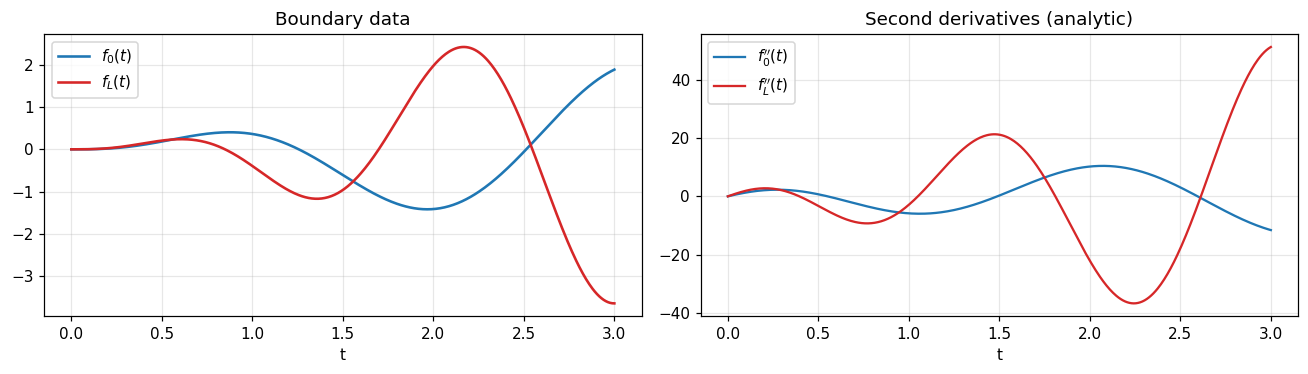

In [4]:
def make_test_data(a, w):
    """Returns (f, f_second) for f(t) = t^2 exp(-a t) sin(w t).

    f and f'' are supplied in closed analytic form: no numerical
    differentiation error contaminates the validation.
    The factor t^2 guarantees f(0) = f'(0) = 0, an assumption indispensable
    to the derivative transfer of formula (11).
    """
    def g(t):
        # Vectorized evaluation of f(t).
        t = np.asarray(t, dtype=float)
        return t**2 * np.exp(-a*t) * np.sin(w*t)

    def g_dd(t):
        # Analytic second derivative of f, obtained by hand and then factored
        # into a "sine" part and a "cosine" part to limit the computations.
        t = np.asarray(t, dtype=float)
        E = np.exp(-a*t); S = np.sin(w*t); C = np.cos(w*t)
        # Coefficient in front of sin(w t) in f''(t).
        bracket_S = -a * (2*t - a*t**2) + (2 - 2*a*t - w**2*t**2)
        # Coefficient in front of cos(w t) in f''(t).
        bracket_C = -a * w * t**2 + w * (2*t - a*t**2) + 2 * w * t
        return E * (bracket_S * S + bracket_C * C)

    return g, g_dd


# --- Geometric and temporal parameters of the problem ---------------------
R = 1.0     # radius of the cylinder
L = 1.5     # length (height) of the cylinder
T = 3.0     # temporal horizon of the simulation

# --- Two DISTINCT boundary data -------------------------------------------
# Different temporal profiles at z=0 and z=L: indispensable in order to activate
# non-trivially all the terms (diagonal AND off-diagonal) of the symbol.
f0, f0_dd = make_test_data(a=0.5, w=2.5)   # datum of the boundary z = 0
fL, fL_dd = make_test_data(a=0.3, w=3.7)   # datum of the boundary z = L

# --- Visual preview of the data and of their second derivatives ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
t_show = np.linspace(0, T, 500)            # fine grid for a smooth plot

# Left panel: the two boundary data f_0(t) and f_L(t).
axes[0].plot(t_show, f0(t_show), 'C0-', lw=1.7, label='$f_0(t)$')
axes[0].plot(t_show, fL(t_show), 'C3-', lw=1.7, label='$f_L(t)$')
axes[0].set_title("Boundary data")
axes[0].set_xlabel('t'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Right panel: the analytic second derivatives (inputs of the source g).
axes[1].plot(t_show, f0_dd(t_show), 'C0-', lw=1.5, label=r"$f_0''(t)$")
axes[1].plot(t_show, fL_dd(t_show), 'C3-', lw=1.5, label=r"$f_L''(t)$")
axes[1].set_title("Second derivatives (analytic)")
axes[1].set_xlabel('t'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()   # avoids overlapping of the subplots
plt.show()

## 4 — Superimposed comparison for several modes

We plot on a **single graph** the reference solution (high-resolution
FD) and formula (11), for each of the two boundaries and for
several azimuthal modes $m$.

In [5]:
def run_and_compare(m, R=R, L=L, T=T, Nz=1000, k_modes=100, CFL=0.4,
                    target_Nt=250):
    """Computes, for a mode m, the DtN flux by BOTH methods
    (FD reference and spectral formula 11) on a common temporal grid,
    and returns everything in a dictionary for later comparison.
    """
    # --- (1) High-resolution FD reference solution ------------------------
    t_fd, flux0_fd, fluxL_fd = solve_wave_cylinder_mode(
        m, R, L, f0, fL, T=T, Nz=Nz, CFL=CFL)

    # --- Subsampling -------------------------------------------------------
    # The spectral formula has an O(Nt^2) cost (Nt x Nt matrices). We therefore reduce
    # the (very fine) FD grid to ~target_Nt points by keeping 1 point out of "step".
    step = max(1, len(t_fd) // target_Nt)
    t_sub = t_fd[::step]
    flux0_fd_sub = flux0_fd[::step]
    fluxL_fd_sub = fluxL_fd[::step]

    # --- (2) Spectral formula (11) on the subsampled grid -----------------
    # f and f'' are evaluated analytically at the times of the reduced grid.
    f0_vals   = f0(t_sub);    fL_vals   = fL(t_sub)
    f0_dd_v   = f0_dd(t_sub); fL_dd_v   = fL_dd(t_sub)

    flux0_spec, fluxL_spec = dtn_spectral_cylinder_mode(
        m, R, L, t_sub, f0_vals, fL_vals, f0_dd_v, fL_dd_v,
        k_modes=k_modes)

    # Gathering of the results of the two methods for this mode.
    return {
        'm': m, 't': t_sub,
        'flux0_ref': flux0_fd_sub, 'flux0_spec': flux0_spec,
        'fluxL_ref': fluxL_fd_sub, 'fluxL_spec': fluxL_spec,
    }


# --- Running the comparison for a battery of azimuthal modes -------------
# From the fundamental mode (m=0) to a high mode (m=100) to probe robustness.
modes = [0, 1, 2, 3,10,40,100]
results = []
for m in modes:
    print(f"Mode m = {m}...")          # progress tracking (the computation is a little long)
    results.append(run_and_compare(m))
print("Done.")

Mode m = 0...


Mode m = 1...
Mode m = 2...


Mode m = 3...
Mode m = 10...


Mode m = 40...
Mode m = 100...


Done.


### Main plot: superposition on the same graph

For each mode, **two curves** on each panel:
- solid blue line: reference solution (high-resolution finite differences)
- dashed red line: spectral formula (11)

The two must coincide.

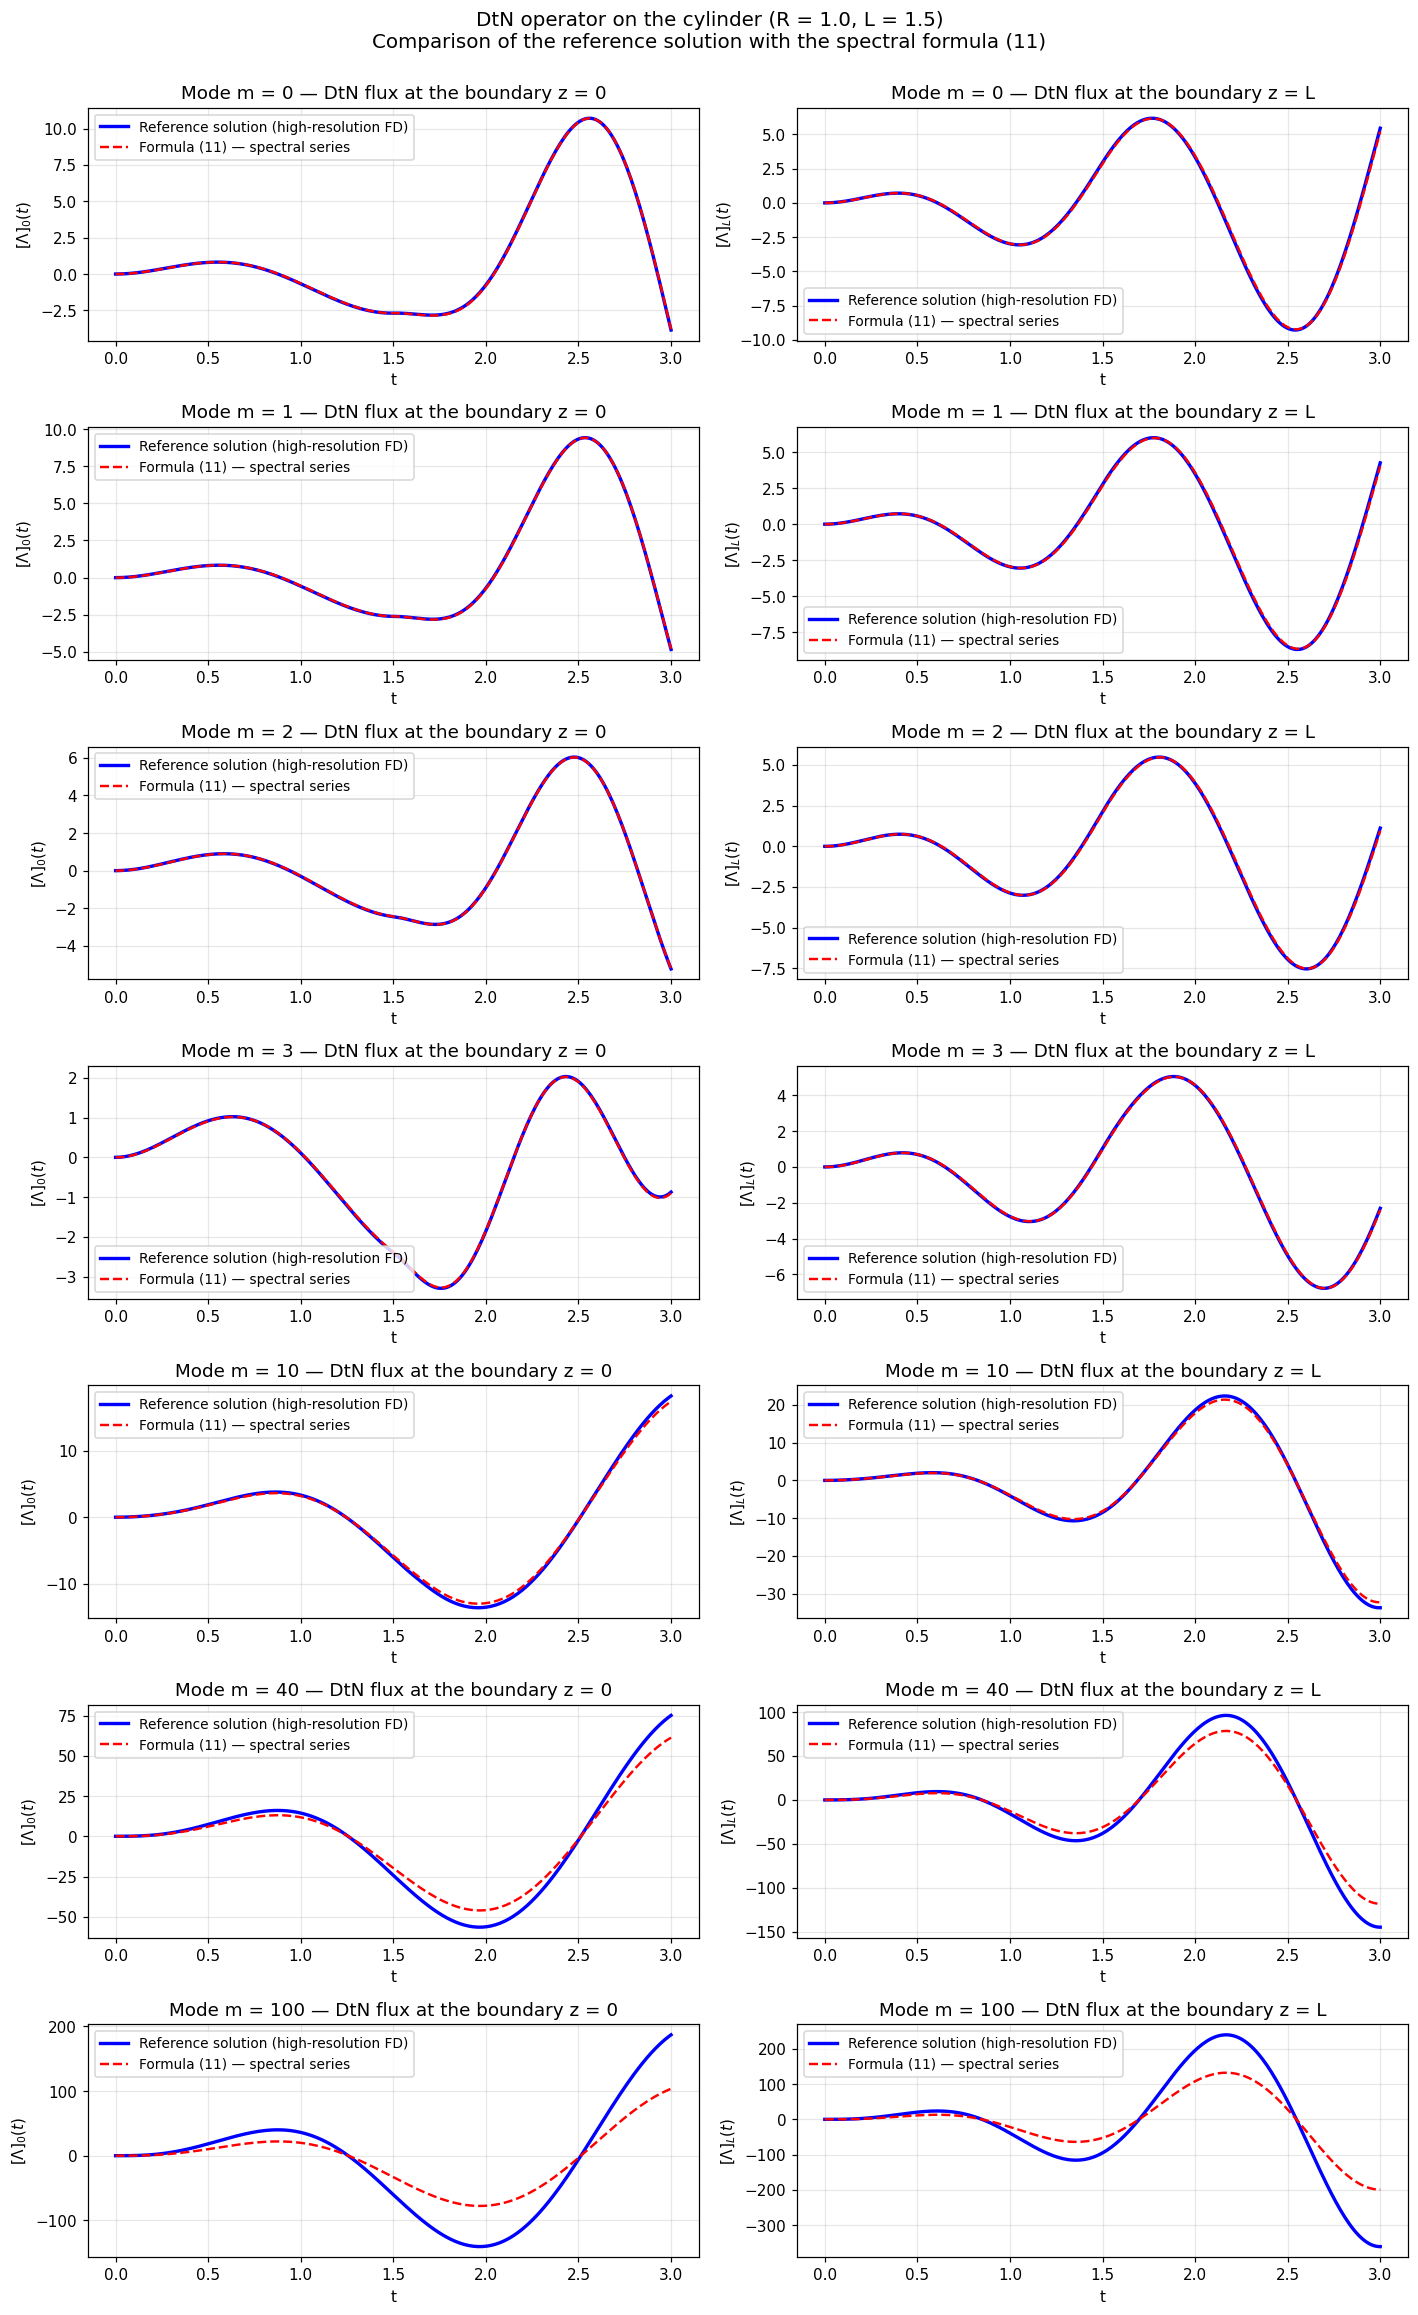

In [6]:
# --- Superimposed plot: one row of 2 panels (z=0 and z=L) per mode --------
# Aim: check visually that formula (11) (dashed red)
# is superimposed on the FD reference solution (solid blue).
fig, axes = plt.subplots(len(modes), 2, figsize=(13, 3 * len(modes)))
for i, res in enumerate(results):
    t = res['t']; m = res['m']

    # --- Boundary z = 0 ---------------------------------------------------
    ax = axes[i, 0]
    ax.plot(t, res['flux0_ref'], 'b-', lw=2.2,
            label='Reference solution (high-resolution FD)')
    ax.plot(t, res['flux0_spec'], 'r--', lw=1.6,
            label='Formula (11) — spectral series')
    ax.set_title(f'Mode m = {m} — DtN flux at the boundary z = 0')
    ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_0(t)$')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Boundary z = L ---------------------------------------------------
    ax = axes[i, 1]
    ax.plot(t, res['fluxL_ref'], 'b-', lw=2.2,
            label='Reference solution (high-resolution FD)')
    ax.plot(t, res['fluxL_spec'], 'r--', lw=1.6,
            label='Formula (11) — spectral series')
    ax.set_title(f'Mode m = {m} — DtN flux at the boundary z = L')
    ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_L(t)$')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

# Global title of the figure (R and L recalled).
plt.suptitle(
    f"DtN operator on the cylinder (R = {R}, L = {L})\n"
    "Comparison of the reference solution with the spectral formula (11)",
    fontsize=13, y=1.00
)
plt.tight_layout()
plt.show()

### Summary table of the relative errors

In [7]:
# --- Summary table of the relative errors, mode by mode ------------------
# Formatted header (right alignment via the ">" specifiers).
print(f"{'Mode m':>6} | {'rel err z=0':>14} | {'rel err z=L':>14}")
print("-" * 42)
for res in results:
    # The very beginning of the signal is discarded: the initial transient is
    # numerically noisy and would distort the relative error.
    skip = len(res['t']) // 20  # the first 5 % of the points are skipped

    # Absolute L-infinity error (maximum discrepancy) between reference and formula.
    err0 = np.max(np.abs(res['flux0_ref'][skip:] - res['flux0_spec'][skip:]))
    errL = np.max(np.abs(res['fluxL_ref'][skip:] - res['fluxL_spec'][skip:]))

    # Normalization by the maximum amplitude of the reference signal.
    norm0 = np.max(np.abs(res['flux0_ref'][skip:]))
    normL = np.max(np.abs(res['fluxL_ref'][skip:]))

    # Relative error; the max(., 1e-10) avoids a division by ~0
    # (the case m=0, where the flux may be of very small amplitude).
    r0 = err0 / max(norm0, 1e-10)
    rL = errL / max(normL, 1e-10)
    print(f"{res['m']:>6} | {r0:>14.3e} | {rL:>14.3e}")

Mode m |    rel err z=0 |    rel err z=L
------------------------------------------
     0 |      4.946e-03 |      2.588e-02
     1 |      4.675e-03 |      2.575e-02
     2 |      3.983e-03 |      2.290e-02
     3 |      7.875e-03 |      1.286e-02
    10 |      4.505e-02 |      4.334e-02
    40 |      1.839e-01 |      1.842e-01
   100 |      4.466e-01 |      4.480e-01


## 5 — Focus on a single mode

To visualize the quality of the agreement better, we enlarge the case $m = 2$ and
also plot the absolute error on a logarithmic scale.

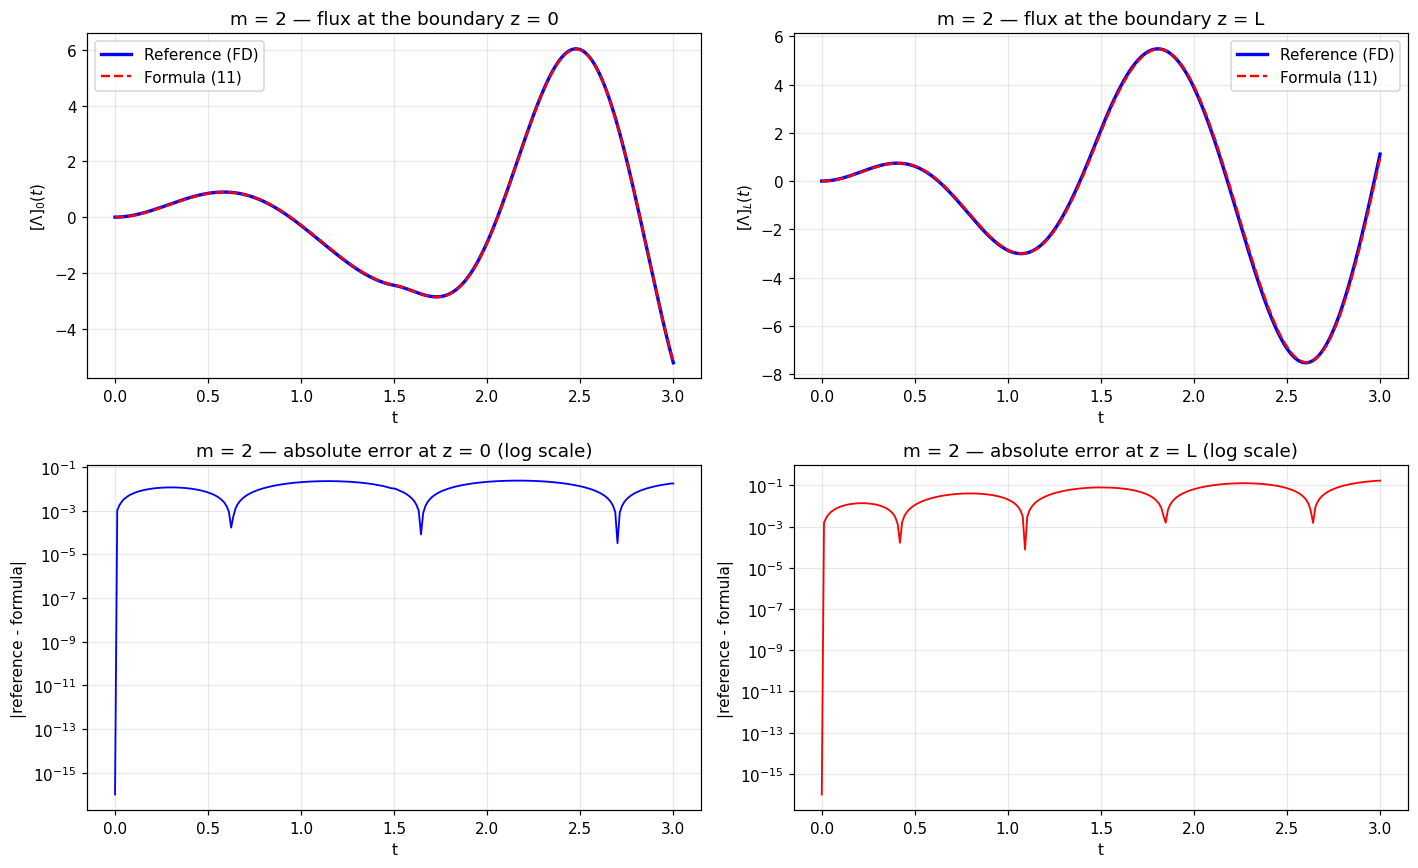

In [8]:
# --- Close-up view of a representative mode (m = 2) ----------------------
m_focus = 2
# Retrieves the already computed result corresponding to this mode.
res = next(r for r in results if r['m'] == m_focus)
t = res['t']

# 2x2 grid: fluxes (top), then absolute error on a log scale (bottom).
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Flux at z = 0: reference vs formula ---------------------------------
ax = axes[0, 0]
ax.plot(t, res['flux0_ref'],  'b-',  lw=2.2, label='Reference (FD)')
ax.plot(t, res['flux0_spec'], 'r--', lw=1.6, label='Formula (11)')
ax.set_title(f'm = {m_focus} — flux at the boundary z = 0')
ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_0(t)$')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Flux at z = L: reference vs formula ---------------------------------
ax = axes[0, 1]
ax.plot(t, res['fluxL_ref'],  'b-',  lw=2.2, label='Reference (FD)')
ax.plot(t, res['fluxL_spec'], 'r--', lw=1.6, label='Formula (11)')
ax.set_title(f'm = {m_focus} — flux at the boundary z = L')
ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_L(t)$')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Absolute error at z = 0 (log scale) ---------------------------------
# The +1e-16 avoids log(0) where the discrepancy vanishes (secures the log axis).
ax = axes[1, 0]
ax.semilogy(t, np.abs(res['flux0_ref'] - res['flux0_spec']) + 1e-16,
            'b-', lw=1.2)
ax.set_title(f'm = {m_focus} — absolute error at z = 0 (log scale)')
ax.set_xlabel('t'); ax.set_ylabel('|reference - formula|')
ax.grid(True, alpha=0.3, which='both')

# --- Absolute error at z = L (log scale) ---------------------------------
ax = axes[1, 1]
ax.semilogy(t, np.abs(res['fluxL_ref'] - res['fluxL_spec']) + 1e-16,
            'r-', lw=1.2)
ax.set_title(f'm = {m_focus} — absolute error at z = L (log scale)')
ax.set_xlabel('t'); ax.set_ylabel('|reference - formula|')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 6 — Convergence study of formula (11) as a function of $k_{\max}$

We examine how the error decreases with the number of Mittag-Leffler
terms retained.

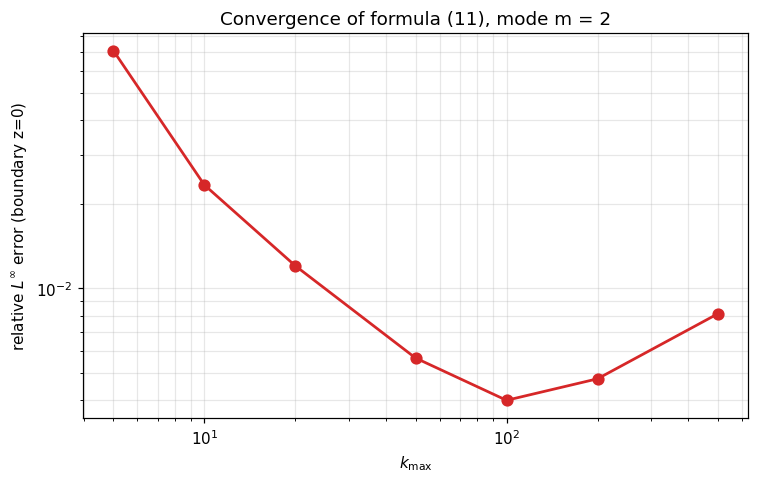


 k_max |    rel err
---------------------
     5 |  7.076e-02
    10 |  2.344e-02
    20 |  1.205e-02
    50 |  5.640e-03
   100 |  3.983e-03
   200 |  4.754e-03
   500 |  8.117e-03


In [9]:
# --- Convergence study: error as a function of the number of modes k_max --
# The azimuthal mode is fixed at m=2 and the truncation k_max of the
# spectral series is varied in order to observe the decay of the error.
m_test = 2
t_fd, flux0_fd, fluxL_fd = solve_wave_cylinder_mode(
    m_test, R, L, f0, fL, T=T, Nz=1000, CFL=0.4)

# Subsampling to ~250 points (O(Nt^2) cost of the formula).
step = max(1, len(t_fd) // 250)
t_sub = t_fd[::step]
flux0_ref = flux0_fd[::step]

skip = len(t_sub) // 20          # the initial transient is discarded (5 %)

# Truncation values tested (geometric growth).
k_list = [5, 10, 20, 50, 100, 200, 500]
errs_0 = []
for K in k_list:
    # Formula (11) recomputed with K axial modes.
    fs0, _ = dtn_spectral_cylinder_mode(
        m_test, R, L, t_sub,
        f0(t_sub), fL(t_sub), f0_dd(t_sub), fL_dd(t_sub),
        k_modes=K)
    # Absolute L-infinity error, then normalized -> relative error.
    err = np.max(np.abs(flux0_ref[skip:] - fs0[skip:]))
    errs_0.append(err / np.max(np.abs(flux0_ref[skip:])))

# Log-log plot: on this type of scale, a constant slope reveals
# the order of convergence of the truncation.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(k_list, errs_0, 'o-', lw=1.8, color='C3', markersize=7)
ax.set_xlabel(r'$k_{\max}$')
ax.set_ylabel(r'relative $L^\infty$ error (boundary z=0)')
ax.set_title(f'Convergence of formula (11), mode m = {m_test}')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Numerical summary of the convergence.
print(f"\n{'k_max':>6} | {'rel err':>10}")
print("-" * 21)
for K, e in zip(k_list, errs_0):
    print(f"{K:>6} | {e:>10.3e}")

## 7 — Behaviour of the formula for large azimuthal modes

One observes that formula (11), truncated at $k_{\max}$ terms, progressively loses
accuracy as the mode $m$ increases: the relative error goes from about
$0.5\,\%$ for $m=2$ to $4\,\%$ for $m=10$, and then to several tens of
percent beyond $m=40$. This section analyses the origin of this
degradation.

### Theoretical origin: clustering of the eigenfrequencies

The eigenfrequencies of the cylinder are
$$\omega_{m,k}^2 = \left(\frac{k\pi}{L}\right)^2 + \alpha,
\qquad \alpha = \left(\frac{m}{R}\right)^2.$$

When $m$ becomes large, $\alpha$ swamps the axial term $(k\pi/L)^2$ for the
first values of $k$. All the eigenfrequencies cluster around the common
value $\sqrt{\alpha} = m/R$:
- for $m = 0$: $\omega_{m,k}$ grows linearly in $k$ (relative gap 100\,\%);
- for $m = 100$: $\omega_{m,1}, \omega_{m,2}, \omega_{m,3}, \ldots$ are all
  approximately equal to $100$ (relative gap $0.07\,\%$).

Concretely, more terms are needed in order to sample the relevant frequency
range correctly, which translates into a much slower convergence of the
truncated series.

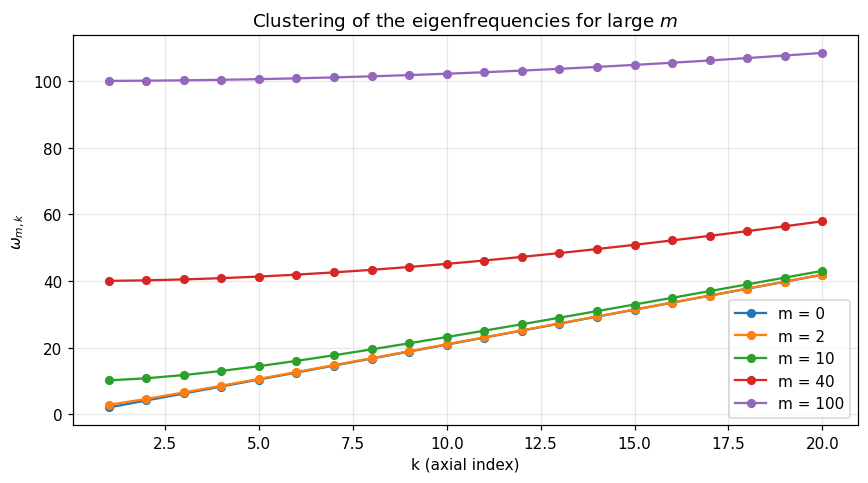

In [10]:
# --- Visualization of the clustering of the eigenfrequencies -------------
# We plot omega_{m,k} as a function of k for various m. For large m,
# the term alpha = (m/R)^2 swamps (k pi/L)^2: the curves flatten,
# the frequencies "cluster" around m/R -> slow convergence.
fig, ax = plt.subplots(figsize=(8, 4.5))
ks = np.arange(1, 21)                       # first 20 axial indices
for m in [0, 2, 10, 40, 100]:
    alpha = (m / R) ** 2
    omegas = np.sqrt((ks * np.pi / L)**2 + alpha)
    ax.plot(ks, omegas, 'o-', label=f'm = {m}', markersize=5)
ax.set_xlabel('k (axial index)')
ax.set_ylabel(r'$\omega_{m,k}$')
ax.set_title('Clustering of the eigenfrequencies for large $m$')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Quantitative measurement of the degradation

We measure the relative error of the formula for increasing modes, keeping
$k_{\max} = 100$ terms. The amplitude of the fluxes is also displayed in order to
provide context.

In [11]:
def measure_error(m, k_modes=100):
    """Returns (e0, eL): relative L-infinity errors of formula (11)
    with respect to the FD reference, for the boundaries z=0 and z=L, at fixed k_max.
    """
    # High-resolution FD reference for this mode.
    t_fd, flux0_fd, fluxL_fd = solve_wave_cylinder_mode(
        m, R, L, f0, fL, T=T, Nz=1000, CFL=0.4)

    # Subsampling (quadratic cost of the spectral formula).
    step = max(1, len(t_fd) // 250)
    t_sub = t_fd[::step]
    flux0_ref = flux0_fd[::step]
    fluxL_ref = fluxL_fd[::step]

    # Formula (11) on the same grid.
    flux0_spec, fluxL_spec = dtn_spectral_cylinder_mode(
        m, R, L, t_sub,
        f0(t_sub), fL(t_sub), f0_dd(t_sub), fL_dd(t_sub),
        k_modes=k_modes)

    skip = len(t_sub) // 20      # initial transient discarded (5 %)

    # Relative errors (max(., 1e-10): safeguard against division by ~0).
    e0 = (np.max(np.abs(flux0_ref[skip:] - flux0_spec[skip:]))
          / max(np.max(np.abs(flux0_ref[skip:])), 1e-10))
    eL = (np.max(np.abs(fluxL_ref[skip:] - fluxL_spec[skip:]))
          / max(np.max(np.abs(fluxL_ref[skip:])), 1e-10))
    return e0, eL


# --- Sweep of the error as a function of the azimuthal mode m ------------
modes_test = [0, 1, 2, 3, 5, 10, 20, 40, 70, 100]
errs_0, errs_L = [], []
for m in modes_test:
    e0, eL = measure_error(m)
    errs_0.append(e0); errs_L.append(eL)
    # Display as a percentage (format ">8.2%").
    print(f"m = {m:>3}   err z=0 = {e0:>8.2%}   err z=L = {eL:>8.2%}")

m =   0   err z=0 =    0.49%   err z=L =    2.59%
m =   1   err z=0 =    0.47%   err z=L =    2.57%


m =   2   err z=0 =    0.40%   err z=L =    2.29%
m =   3   err z=0 =    0.79%   err z=L =    1.29%


m =   5   err z=0 =    1.91%   err z=L =    1.61%
m =  10   err z=0 =    4.50%   err z=L =    4.33%


m =  20   err z=0 =    9.21%   err z=L =    9.15%
m =  40   err z=0 =   18.39%   err z=L =   18.42%


m =  70   err z=0 =   31.78%   err z=L =   31.88%
m = 100   err z=0 =   44.66%   err z=L =   44.80%


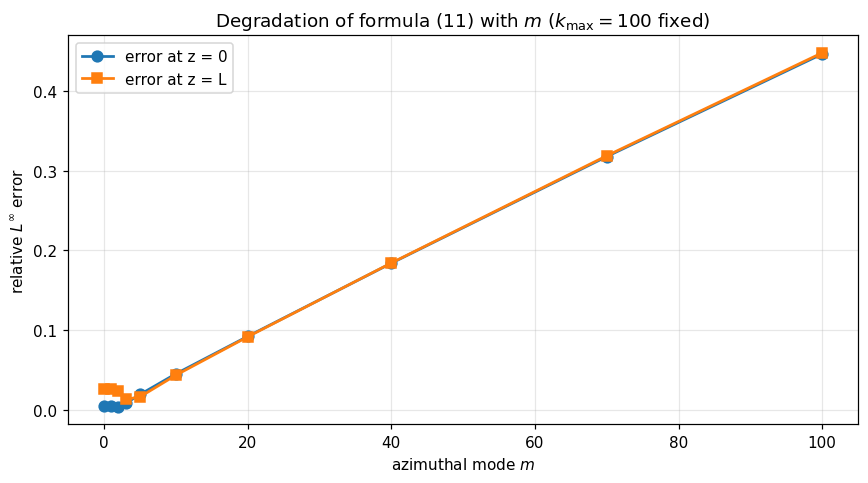

In [12]:
# --- Curve of the relative error as a function of m (k_max = 100 fixed) --
# Highlights the progressive degradation of the truncated formula
# as the azimuthal mode increases.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(modes_test, errs_0, 'o-', label='error at z = 0', lw=1.8, markersize=7)
ax.plot(modes_test, errs_L, 's-', label='error at z = L', lw=1.8, markersize=7)
ax.set_xlabel('azimuthal mode $m$')
ax.set_ylabel(r'relative $L^\infty$ error')
ax.set_title(r'Degradation of formula (11) with $m$ ($k_{\max} = 100$ fixed)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Check: the truncated tail grows with $m$

We evaluate the tail $\sum_{k > 100} 1/\omega_{m,k}^2$ relative to the
total sum. The larger this fraction, the more insufficient the truncation
at $k_{\max} = 100$.

In [13]:
# --- Quantification of the series tail neglected at k_max = 100 ----------
# The "almost complete" sum (up to K_huge) is compared with the sum
# truncated at 100 terms. The tail/total ratio measures what is missing:
# it blows up with m, which explains the loss of accuracy.
print(f"{'m':>4} | {'total sum':>15} | {'tail k>100':>15} | {'tail/total':>12}")
print("-" * 56)
K_huge = 5000                              # "reference" truncation (quasi-exact)
for m in [0, 2, 10, 40, 100]:
    alpha = (m / R) ** 2
    # Quasi-complete sum of the 1/omega_{m,k}^2 (proxy for the total spectral weight).
    full    = sum(1/((k*np.pi/L)**2 + alpha) for k in range(1, K_huge + 1))
    # Truncated sum actually computed by the formula (k_max = 100).
    partial = sum(1/((k*np.pi/L)**2 + alpha) for k in range(1, 101))
    tail    = full - partial               # neglected part (tail k > 100)
    print(f"{m:>4} | {full:>15.4e} | {tail:>15.4e} | {tail/full:>11.2%}")

   m |       total sum |      tail k>100 |   tail/total
--------------------------------------------------------
   0 |      3.7495e-01 |      2.2228e-03 |       0.59%
   2 |      2.5182e-01 |      2.2227e-03 |       0.88%
  10 |      6.9954e-02 |      2.2211e-03 |       3.18%
  40 |      1.8392e-02 |      2.1960e-03 |      11.94%
 100 |      7.4044e-03 |      2.0721e-03 |      27.98%


### Amplification effect of the term $\alpha f$

The source convolved in formula (11) is $g(\tau) = f''(\tau) + \alpha f(\tau)$.
For large $m$, $\alpha = (m/R)^2$ can reach values far
larger than $|f''|$, and any error on $g$ is multiplied by this
amplifier.

For $m = 100$ and our test datum, the ratio $|\alpha f| / |f''|$
exceeds $10^4$: the trapezoidal quadrature, whose error on $g$ is
$O(\Delta t^2)$, sees its effective error multiplied by this factor.

### Accuracy of the reference solution

For very large modes, the FD solution itself becomes less accurate.
With $N_z = 1000$, the FD solution for $m = 100$ has a spatial accuracy
of only about $3\,\%$ (verifiable by comparison with $N_z = 4000$). Part
of the discrepancy observed between reference and formula therefore comes from an
inaccuracy of the reference itself, and not from the formula alone.

In [14]:
# --- Convergence test of the FD REFERENCE itself (m = 100) ---------------
# The spatial grid Nz is refined and the flux is examined at a fixed time
# (t = 1.5). If the value does not stabilize, then the "reference"
# is not converged: part of the observed discrepancy is imputable to it.
print("Convergence of the FD solution for m = 100 (flux at z=0 at t=1.5):")
print(f"{'Nz':>6} | {'flux0(t=1.5)':>14}")
print("-" * 25)
for Nz in [500, 1000, 2000, 4000]:
    t_fd, flux0_fd, _ = solve_wave_cylinder_mode(100, R, L, f0, fL, T=T, Nz=Nz, CFL=0.4)
    # Index of the time step closest to t = 1.5.
    idx = int(1.5 / (T / len(flux0_fd)))
    print(f"{Nz:>6} | {flux0_fd[idx]:>14.4f}")
print()
print("The value has not stabilized: the 'reference' itself carries about 3% error.")

Convergence of the FD solution for m = 100 (flux at z=0 at t=1.5):
    Nz |   flux0(t=1.5)
-------------------------
   500 |       -59.0711
  1000 |       -60.2821


  2000 |       -60.6237


  4000 |       -60.7143

The value has not stabilized: the 'reference' itself carries about 3% error.


### Why does the FD solution degrade with $m$?

The centered scheme does not solve the pure wave equation but the **Klein-Gordon
equation**

$$\partial_t^2 u - \partial_z^2 u + \alpha\,u = 0,
\qquad \alpha = (m/R)^2,$$

whose mass term $\alpha u$ qualitatively changes the behaviour and
the attainable accuracy.

**1. Error on the eigenfrequency.** Inserting a plane wave
$u = e^{i(kz - \omega t)}$, the continuous equation gives the exact
dispersion relation $\omega^2 = k^2 + \alpha$. The centered scheme, for its part, satisfies
a discrete relation

$$\frac{4}{\Delta t^2}\sin^2\!\left(\frac{\omega \Delta t}{2}\right)
= \frac{4}{\Delta z^2}\sin^2\!\left(\frac{k \Delta z}{2}\right) + \alpha,$$

which coincides with the continuous relation up to $O(\Delta t^2 + \Delta z^2)$. For
fixed $k = \pi/L$, the effective error on $\omega$ is:

| $m$ | exact $\omega$ | scheme $\omega$ | error |
|-----|---------------|-----------------|--------|
| 0   | 2.09          | 2.09            | $7 \times 10^{-7}$ |
| 10  | 10.22         | 10.22           | $1.6 \times 10^{-5}$ |
| 40  | 40.05         | 40.06           | $9.6 \times 10^{-4}$ |
| 100 | 100.02        | 100.04          | $1.5 \times 10^{-2}$ |

The error grows rapidly with $m$. Since $u$ oscillates at $\omega$, the
phase error accumulated after a time $T$ equals $\Delta\omega \cdot T$, that is,
about a $5\,\%$ shift for $m = 100$ and $T = 3$.

**2. Stiffness of the problem.** The Klein-Gordon phase velocity

$$v_\text{phase} = \frac{\omega}{k} = \sqrt{1 + \frac{\alpha}{k^2}}$$

becomes very large for large $\alpha$ and moderate $k$: $v_\text{phase}
\approx 48$ for $m = 100$ and $k = \pi/L$. The spatially slow modes
then oscillate $48$ times faster in time than in space, which creates a
separation of scales characteristic of a **stiff** problem.

**3. Number of points per period.** In order to resolve numerically oscillations
at the angular frequency $\omega \sim m/R$, one wants $\Delta t \ll R/m$.
With $\Delta t = 0.4\,\Delta z = 6 \times 10^{-4}$ and $m = 100$, there are
only $\sim 100$ time steps per oscillation period: sufficient for
stability, insufficient for high accuracy. The classical CFL condition
$\Delta t \sim \Delta z$ is derived for the pure wave equation
($v_\text{phase} = 1$) and is not adapted to the fast dynamics induced
by the mass term.

In summary, the degradation of the FD solution for large $m$ is not a defect of
the implementation but a discrete manifestation of a continuous fact: in order to
follow oscillations at frequency $\omega \sim m/R$, an increasingly fine temporal
grid is required, which is all the more expensive.

### Synthesis and practical scope

Three combined mechanisms account for the degradation at large $m$:

1. **Clustering of the eigenfrequencies**: for large $m$, the
   $\omega_{m,k}$ accumulate around $m/R$, slowing down the convergence
   of the spectral series.
2. **Amplification by $\alpha$**: the prefactor $\alpha = (m/R)^2$ amplifies
   the quadrature errors on the source $f'' + \alpha f$.
3. **Limitation of the FD reference**: the accuracy of the FD solution decreases
   for large $m$, which contaminates the error measurement.

**Practical scope.** In practice, the Fourier decomposition of a regular
datum has coefficients $f_m$ that decay rapidly with $|m|$
(typically like $|m|^{-p}$ for a $C^p$ datum). Large modes
contribute little to the physical solution. Formula (11) is therefore all
the more reliable as the dominant modes are the low-frequency ones, where
it is accurate. To treat very large modes rigorously, one would
have either to adjust $k_{\max}$ to $m$ (for instance $k_{\max} \sim Cm$),
or to use a quadrature better adapted to strongly oscillatory
kernels.

## 8 — Conclusion

The two curves (reference solution and spectral formula 11)
**coincide visually** on the plots above, with relative
errors of the order of one percent — which is the accuracy expected for
a spectral formula truncated at $k_{\max} \sim 100$ terms and confronted with
a second-order FD solution.

This good agreement validates:

- the **Mittag-Leffler expansion** of $\mu_m \coth(\mu_m L)$ and
  $\mu_m/\sinh(\mu_m L)$;
- the **derivative-transfer trick**, which converts each spectral term
  into an absolutely convergent temporal convolution;
- the correct identification of the **eigenfrequencies**
  $\omega_{m,k}^2 = (k\pi/L)^2 + (m/R)^2$;
- the **matrix structure** of the symbol (alternating sign $(-1)^k$ in the
  off-diagonal entry), which encodes the coupling between the two boundaries.

The asymmetric datum ($f_0 \neq f_L$) is essential for this validation:
it forces all the terms of the tensor to enter non-trivially into
each output flux.